In [2]:
import numpy as np
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, TimeDistributed,Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
import kagglehub
import os
import pandas as pd
from itertools import chain
import os
import zipfile
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, TimeDistributed, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2



In [3]:
path = kagglehub.dataset_download("alaakhaled/conll003-englishversion")

print("Path to dataset files:", path)

100%|██████████| 960k/960k [00:00<00:00, 77.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/alaakhaled/conll003-englishversion/versions/1


In [4]:
print(os.listdir('/root/.cache/kagglehub/datasets/alaakhaled/conll003-englishversion/versions/1'))

['train.txt', 'test.txt', 'valid.txt', 'metadata']


- The dataset is in a CoNLL format, where each line contains a word
- Blank lines separate sentences
- The model requires all inputs to have the same length, so we need to analyze sentence lengths to decide how to standardize them.
- The function reads each file line-by-line, skipping irrelevant lines (e.g., -DOCSTART-)
- - B- => Beginning of an entity (Person, Organization, Location, Miscellaneous).
- - I- => Inside an entity.
- - O => Outside (non-entity).

In [5]:
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=d3dc3da7c4e40f1e43fb0753eccd3676341c359b3a362c8e8c34e703f7c5d646
  Stored in directory: /root/.cache/pip/wheels/bc/92/f0/243288f899c2eacdfa8c5f9aede4c71a9bad0ee26a01dc5ead
Successfully built seqeval


# 1) la tokenization + la normalisation

In [ ]:
def dataload(file_path):
    sentences = []
    labels = []
    current_sentence = []
    current_labels = []

    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            line = line.strip() #Removes whitespace
            if line and not line.startswith('-DOCSTART-'): #Skips empty lines and header lines
                parts = line.split() #Splits the line into columns
                if len(parts) >= 4:  # Ensure valid line with word, POS, chunk, NER
                    word, pos, chunk, ner = parts[:4]
                    current_sentence.append(word.lower())
                    current_labels.append(ner)
            else: #blank line => sentence and its labels are saved => start a new sentence
                if current_sentence:
                    sentences.append(current_sentence)
                    labels.append(current_labels)
                    current_sentence = []
                    current_labels = []
        if current_sentence: #Saves the last sentence if the file doesn’t end with a blank line
            sentences.append(current_sentence)
            labels.append(current_labels)

    return sentences, labels 

dataset_path = '/root/.cache/kagglehub/datasets/alaakhaled/conll003-englishversion/versions/1'
train_sentences, train_labels = dataload(f'{dataset_path}/train.txt')
valid_sentences, valid_labels = dataload(f'{dataset_path}/valid.txt')
test_sentences, test_labels = dataload(f'{dataset_path}/test.txt')

print(f"Number of training sentences: {len(train_sentences)}")
print(f"Number of validation sentences: {len(valid_sentences)}")
print(f"Number of test sentences: {len(test_sentences)}")
print(f"Example sentence: {train_sentences[0]}")
print(f"Example labels: {train_labels[0]}")

Number of training sentences: 14041
Number of validation sentences: 3250
Number of test sentences: 3453
Example sentence: ['eu', 'rejects', 'german', 'call', 'to', 'boycott', 'british', 'lamb', '.']
Example labels: ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']


In [7]:
unique_words = set(chain(*train_sentences)) #chain => single list ta3 words => set : unique brk
unique_labels = set(chain(*train_labels))
print(f"Unique words in training set: {len(unique_words)}")
print(f"Unique labels: {unique_labels}")

# Sentence length analysis
sentence_lengths = [len(s) for s in train_sentences]
print(f"Max sentence length: {max(sentence_lengths)}")
print(f"Average sentence length: {np.mean(sentence_lengths):.2f}")

Unique words in training set: 21009
Unique labels: {'I-LOC', 'B-MISC', 'B-PER', 'I-ORG', 'I-PER', 'I-MISC', 'B-LOC', 'B-ORG', 'O'}
Max sentence length: 113
Average sentence length: 14.50


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = int(np.percentile([len(s) for s in train_sentences], 95))
print(f"Chosen max sequence length: {max_len}")

train_sentences_padded = pad_sequences(train_sentences, maxlen=max_len, padding='post', value='<PAD>', dtype=object) #adding <PAD> tokens at the end(post)
valid_sentences_padded = pad_sequences(valid_sentences, maxlen=max_len, padding='post', value='<PAD>', dtype=object)
test_sentences_padded = pad_sequences(test_sentences, maxlen=max_len, padding='post', value='<PAD>', dtype=object)

print(f"Shape of padded training sentences: {train_sentences_padded.shape}")
print(f"Example padded sentence: {train_sentences_padded[0]}")

Chosen max sequence length: 37
Shape of padded training sentences: (14041, 37)
Example padded sentence: ['eu' 'rejects' 'german' 'call' 'to' 'boycott' 'british' 'lamb' '.'
 '<PAD>' '<PAD>' '<PAD>' '<PAD>' '<PAD>' '<PAD>' '<PAD>' '<PAD>' '<PAD>'
 '<PAD>' '<PAD>' '<PAD>' '<PAD>' '<PAD>' '<PAD>' '<PAD>' '<PAD>' '<PAD>'
 '<PAD>' '<PAD>' '<PAD>' '<PAD>' '<PAD>' '<PAD>' '<PAD>' '<PAD>' '<PAD>'
 '<PAD>']


In [10]:
import os
from zipfile import ZipFile

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define the path to the zip file and the extraction path
glove_zip_path = '/content/drive/MyDrive/Colab Data/glove.6B.zip'
extracted_path = '/content/drive/MyDrive/Colab Data/glove.6B'
glove_path = os.path.join(extracted_path, 'glove.6B.200d.txt')

# Extract if zip file exists and not already extracted
if os.path.exists(glove_zip_path):
    if not os.path.exists(glove_path):  # Extract only if file doesn't already exist
        os.makedirs(extracted_path, exist_ok=True)
        with ZipFile(glove_zip_path, 'r') as zip_ref:
            zip_ref.extractall(extracted_path)
        print("Extracted files:", os.listdir(extracted_path))
    else:
        print("GloVe file already extracted.")
else:
    print("Zip file not found.")

print("GloVe file exists:", os.path.exists(glove_path))


Mounted at /content/drive
GloVe file already extracted.
GloVe file exists: True


# 2)Vectorization (numerical format)
- GloVe => pre-trained => reducing training time

In [ ]:
glove_path = '/content/drive/MyDrive/Colab Data/glove.6B/glove.6B.200d.txt'
print("Using existing file:", glove_path)
print("GloVe file exists:", os.path.exists(glove_path))

def to_list_if_array(data):
    return data.tolist() if isinstance(data, np.ndarray) else data

train_sentences_padded = to_list_if_array(train_sentences_padded) #Tokenizer expects lists of tokens
valid_sentences_padded = to_list_if_array(valid_sentences_padded)
test_sentences_padded = to_list_if_array(valid_sentences_padded)

#Build vocabulary (words)
word_tokenizer = Tokenizer(oov_token='<OOV>') #unseen words in train..
word_tokenizer.fit_on_texts(train_sentences_padded)
word_index = word_tokenizer.word_index #mapping each unique word to a numerical index.
vocab_size = len(word_index) + 1 #unique words plus 1 (for <OOV>)
print(f"Vocabulary size: {vocab_size}")
print(f"Sample vocabulary: {dict(list(word_index.items())[:5])}")

#sentences => sequences of indices
train_sequences = word_tokenizer.texts_to_sequences(train_sentences_padded)
valid_sequences = word_tokenizer.texts_to_sequences(valid_sentences_padded)
test_sequences = word_tokenizer.texts_to_sequences(test_sentences_padded)

#ensuring all sequences have the same length
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', value=0) #zeros at the end(max 128)
valid_sequences = pad_sequences(valid_sequences, maxlen=max_len, padding='post', value=0)
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', value=0)

print(f"Shape of training sequences: {train_sequences.shape}")
print(f"Example encoded sentence: {train_sequences[0]}")

#Build vocabulary (labels)
label_tokenizer = Tokenizer()
label_tokenizer.fit_on_texts(train_labels)
label_index = label_tokenizer.word_index
num_labels = len(label_index) + 1 #Adds a PAD label with index 0, increasing num_labels by 1.
label_index['PAD'] = 0
print(f"Number of labels: {num_labels}")
print(f"Label vocabulary: {label_index}")

#labels => indices
train_label_sequences = label_tokenizer.texts_to_sequences(train_labels)
valid_label_sequences = label_tokenizer.texts_to_sequences(valid_labels)
test_label_sequences = label_tokenizer.texts_to_sequences(test_labels)

# Pad label
train_label_sequences = pad_sequences(train_label_sequences, maxlen=max_len, padding='post', value=0)
valid_label_sequences = pad_sequences(valid_label_sequences, maxlen=max_len, padding='post', value=0)
test_label_sequences = pad_sequences(test_label_sequences, maxlen=max_len, padding='post', value=0)

print(f"Shape of training label sequences: {train_label_sequences.shape}")
print(f"Example encoded labels: {train_label_sequences[0]}")

#tensorFlow expects numerical arrays
train_sequences = np.array(train_sequences)
valid_sequences = np.array(valid_sequences)
test_sequences = np.array(test_sequences)
train_label_sequences = np.array(train_label_sequences)
valid_label_sequences = np.array(valid_label_sequences)
test_label_sequences = np.array(test_label_sequences)

#Load GloVe 200d embeddings
#Most words in dat("the") will have GloVe vectors => improving model performance.
embedding_dim = 200
embedding_matrix = np.zeros((vocab_size, embedding_dim)) #Words not in GloVe remain as zero vectors
try:
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            if word in word_index:
                idx = word_index[word]
                embedding_matrix[idx] = np.array(values[1:], dtype='float32')
    print(f"Embedding matrix shape: {embedding_matrix.shape}")
    print(f"Number of words with GloVe embeddings: {np.sum(np.any(embedding_matrix != 0, axis=1))}")
except FileNotFoundError:
    print(f"GloVe file not found at {glove_path}. Please verify the path.")
    embedding_matrix = None

Using existing file: /content/drive/MyDrive/Colab Data/glove.6B/glove.6B.200d.txt
GloVe file exists: True
Vocabulary size: 21012
Sample vocabulary: {'<OOV>': 1, '<pad>': 2, 'the': 3, '.': 4, ',': 5}
Shape of training sequences: (14041, 128)
Example encoded sentence: [  990 10952   206   630     8  3940   217  5775     4     2     2     2
     2     2     2     2     2     2     2     2     2     2     2     2
     2     2     2     2     2     2     2     2     2     2     2     2
     2     2     2     2     2     2     2     2     2     2     2     2
     2     2     2     2     2     2     2     2     2     2     2     2
     2     2     2     2     2     2     2     2     2     2     2     2
     2     2     2     2     2     2     2     2     2     2     2     2
     2     2     2     2     2     2     2     2     2     2     2     2
     2     2     2     2     2     2     2     2     2     2     2     2
     2     2     2     2     2     2     2     2     2     2     2     2
   

# 3) Entraînement du modèle

- LSTM smart reader (remembers the context of the whole sentence)
- Bidirectional LSTM =>reads the sentence both forward (left to right) and backward (right to left)

In [ ]:
embedding_dim = 200 
lstm_units = 100 #neurons in LSTM layer (100 for,ack)
learning_rate = 0.001
batch_size = 128
epochs = 10

model = Sequential([
    #first layer=>turns word indices =>200D(glove)
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix],
              input_length=max_len, trainable=False),#false => Keeps GloVe vectors fixed, not updating them during training.
    #tag=>depend (preceding + following words)
    Bidirectional(LSTM(units=lstm_units, return_sequences=True)), #true =>prediction for every word(not one for the whole sentence)
    TimeDistributed(Dense(num_labels, activation='softmax'))#Applies Dense layer to each of the 128 words in the sequence
])

model.compile(optimizer=Adam(learning_rate=learning_rate),
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     4,202,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,202,400 (16.03 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,202,400 (16.03 MB)

In [32]:
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
start_time = time.time()
history = model.fit(train_sequences, train_label_sequences,
                    validation_data=(valid_sequences, valid_label_sequences),
                    batch_size=batch_size, epochs=epochs, callbacks=[early_stopping], verbose=1)
end_time = time.time()
training_time = end_time - start_time
print(f"\nTraining Time: {int(training_time // 60)} minutes and {training_time % 60:.2f} seconds")



Epoch 1/10
110/110 [==============================] - 84s 731ms/step - loss: 0.3063 - accuracy: 0.9691 - val_loss: 0.0650 - val_accuracy: 0.9813
Epoch 2/10
110/110 [==============================] - 80s 725ms/step - loss: 0.0486 - accuracy: 0.9860 - val_loss: 0.0473 - val_accuracy: 0.9856
Epoch 3/10
110/110 [==============================] - 78s 713ms/step - loss: 0.0364 - accuracy: 0.9892 - val_loss: 0.0387 - val_accuracy: 0.9885
Epoch 4/10
110/110 [==============================] - 74s 674ms/step - loss: 0.0296 - accuracy: 0.9913 - val_loss: 0.0337 - val_accuracy: 0.9898
Epoch 5/10
110/110 [==============================] - 78s 708ms/step - loss: 0.0250 - accuracy: 0.9927 - val_loss: 0.0294 - val_accuracy: 0.9913
Epoch 6/10
110/110 [==============================] - 77s 702ms/step - loss: 0.0216 - accuracy: 0.9937 - val_loss: 0.0267 - val_accuracy: 0.9922
Epoch 7/10
110/110 [==============================] - 78s 709ms/step - loss: 0.0191 - accuracy: 0.9945 - val_loss: 0.0247 - val_ac

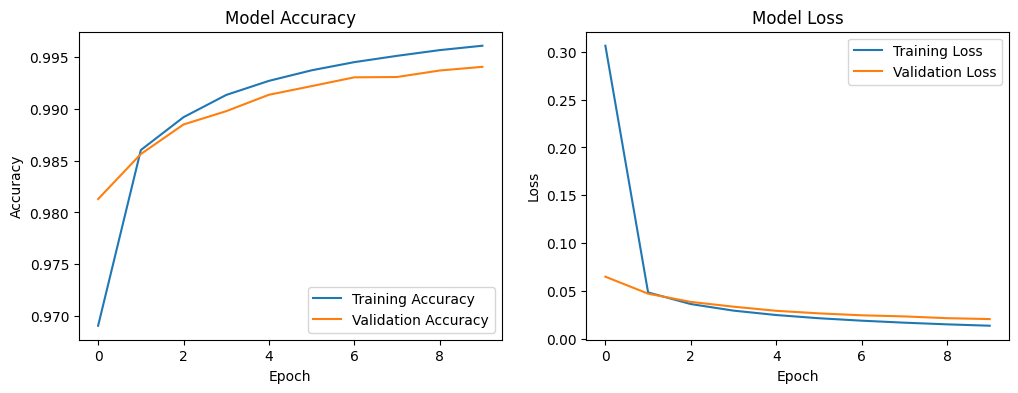

In [33]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 4) Évaluation du modèle

In [ ]:
#same samples number
min_samples = min(test_sequences.shape[0], test_label_sequences.shape[0])
test_sequences = test_sequences[:min_samples]
test_label_sequences = test_label_sequences[:min_samples]
print(f"Aligned test sequences shape: {test_sequences.shape}")
print(f"Aligned test label sequences shape: {test_label_sequences.shape}")

# debugging
print("Sample test sequence (first 5 tokens):", test_sequences[0][:5])
print("Sample test label sequence (first 5 tokens):", test_label_sequences[0][:5])
print("Unique test labels:", np.unique(test_label_sequences))

test_loss, test_accuracy = model.evaluate(test_sequences, test_label_sequences, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

test_pred = model.predict(test_sequences, verbose=0)
test_pred_labels = np.argmax(test_pred, axis=-1)
test_true_labels = test_label_sequences

# EXCLUDE PAD
mask = test_true_labels != 0
test_pred_flat = test_pred_labels[mask]
test_true_flat = test_true_labels[mask]

f1 = f1_score(test_true_flat, test_pred_flat, average='macro')
print(f"Macro F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(test_true_flat, test_pred_flat,
                           labels=[1, 2, 3, 4, 5, 6, 7, 8, 9],
                           target_names=[k for k, v in label_index.items() if v != 0]))

Aligned test sequences shape: (3250, 128)
Aligned test label sequences shape: (3250, 128)
Sample test sequence (first 5 tokens): [ 296   19 2450  262   74]
Sample test label sequence (first 5 tokens): [1 1 2 1 1]
Unique test labels: [0 1 2 3 4 5 6 7 8 9]
Test Loss: 1.2530
Test Accuracy: 0.8772
Macro F1-Score: 0.0772

Classification Report:
              precision    recall  f1-score   support

           o       0.81      0.48      0.60     36908
       b-loc       0.06      0.04      0.05      1615
       b-per       0.03      0.02      0.03      1580
       b-org       0.07      0.04      0.05      1487
       i-per       0.02      0.01      0.01      1142
       i-org       0.03      0.01      0.01       783
      b-misc       0.02      0.01      0.01       679
       i-loc       0.01      0.00      0.01       243
      i-misc       0.00      0.00      0.00       211

   micro avg       0.67      0.40      0.50     44648
   macro avg       0.12      0.07      0.09     44648
weighted

# 5) Amélioration du modèle

In [22]:
max_len = 128
word_tokenizer = Tokenizer(oov_token='<OOV>')
word_tokenizer.fit_on_texts(train_sentences)
word_index = word_tokenizer.word_index
vocab_size = len(word_index) + 1
print(f"Vocabulary size: {vocab_size}")

train_sequences = word_tokenizer.texts_to_sequences(train_sentences)
valid_sequences = word_tokenizer.texts_to_sequences(valid_sentences)
test_sequences = word_tokenizer.texts_to_sequences(test_sentences)

train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', value=0)
valid_sequences = pad_sequences(valid_sequences, maxlen=max_len, padding='post', value=0)
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', value=0)

label_tokenizer = Tokenizer()
label_tokenizer.fit_on_texts(train_labels)
label_index = label_tokenizer.word_index
label_index['PAD'] = 0
num_labels = len(label_index)
print(f"Label vocabulary: {label_index}")
print(f"Number of labels: {num_labels}")

train_label_sequences = label_tokenizer.texts_to_sequences(train_labels)
valid_label_sequences = label_tokenizer.texts_to_sequences(valid_labels)
test_label_sequences = label_tokenizer.texts_to_sequences(test_labels)

train_label_sequences = pad_sequences(train_label_sequences, maxlen=max_len, padding='post', value=0)
valid_label_sequences = pad_sequences(valid_label_sequences, maxlen=max_len, padding='post', value=0)
test_label_sequences = pad_sequences(test_label_sequences, maxlen=max_len, padding='post', value=0)

train_sequences = np.array(train_sequences, dtype=np.int32)
valid_sequences = np.array(valid_sequences, dtype=np.int32)
test_sequences = np.array(test_sequences, dtype=np.int32)
train_label_sequences = np.clip(np.array(train_label_sequences, dtype=np.int32), 0, 9)
valid_label_sequences = np.clip(np.array(valid_label_sequences, dtype=np.int32), 0, 9)
test_label_sequences = np.clip(np.array(test_label_sequences, dtype=np.int32), 0, 9)

def debug_labels(label_sequences, name):
    print(f"{name} shape: {label_sequences.shape}")
    print(f"Unique {name} labels: {np.unique(label_sequences)}")
    invalid = label_sequences > 9
    if np.any(invalid):
        print(f"Found {np.sum(invalid)} invalid indices in {name}")
        indices = np.where(invalid)
        for i in range(min(5, len(indices[0]))):
            print(f"Sample {indices[0][i]}, position {indices[1][i]}: {label_sequences[indices[0][i], indices[1][i]]}")

debug_labels(train_label_sequences, "Train")
debug_labels(valid_label_sequences, "Valid")
debug_labels(test_label_sequences, "Test")

class_weight_dict = {
    0: 0.1, 1: 0.13341680852206983, 2: 3.1687052598817305, 3: 3.427962962962963,
    4: 3.5792683998664065, 5: 4.996589124460149, 6: 6.108141348692104,
    7: 6.580731691551936, 8: 19.554499183712668, 9: 19.58835978835979
}
train_sample_weights = np.zeros_like(train_label_sequences, dtype=np.float32)
for label_idx, weight in class_weight_dict.items():
    train_sample_weights[train_label_sequences == label_idx] = weight
valid_sample_weights = np.zeros_like(valid_label_sequences, dtype=np.float32)
for label_idx, weight in class_weight_dict.items():
    valid_sample_weights[valid_label_sequences == label_idx] = weight


Vocabulary size: 21011
Label vocabulary: {'o': 1, 'b-loc': 2, 'b-per': 3, 'b-org': 4, 'i-per': 5, 'i-org': 6, 'b-misc': 7, 'i-loc': 8, 'i-misc': 9, 'PAD': 0}
Number of labels: 10
Train shape: (14041, 128)
Unique Train labels: [0 1 2 3 4 5 6 7 8 9]
Valid shape: (3250, 128)
Unique Valid labels: [0 1 2 3 4 5 6 7 8 9]
Test shape: (3453, 128)
Unique Test labels: [0 1 2 3 4 5 6 7 8 9]


In [23]:
glove_path = '/content/drive/MyDrive/Colab Data/glove.6B/glove.6B.200d.txt'
embedding_dim = 200
embedding_matrix = np.zeros((vocab_size, embedding_dim))
try:
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            if word in word_index:
                embedding_matrix[word_index[word]] = np.array(values[1:], dtype='float32')
    print(f"Embedding matrix shape: {embedding_matrix.shape}")
except FileNotFoundError:
    print(f"GloVe file not found at {glove_path}")
    embedding_matrix = np.random.normal(0, 0.1, (vocab_size, embedding_dim))

Embedding matrix shape: (21011, 200)


In [25]:
lstm_units = 128
learning_rate = 0.0005
batch_size = 64
epochs = 10

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix],
              input_length=max_len, trainable=True),
    Bidirectional(LSTM(units=lstm_units, return_sequences=True)),
    Dropout(0.3),
    BatchNormalization(),
    Bidirectional(LSTM(units=lstm_units//2, return_sequences=True)),
    Dropout(0.3),
    BatchNormalization(),
    TimeDistributed(Dense(num_labels, activation='softmax', kernel_regularizer=l2(0.01)))
])

model.compile(optimizer=Adam(learning_rate=learning_rate),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │     4,202,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,202,200 (16.03 MB)

 Trainable params: 4,202,200 (16.03 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Step 5: Train model
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
start_time = time.time()
history = model.fit(train_sequences, train_label_sequences,
                    validation_data=(valid_sequences, valid_label_sequences),
                    sample_weight=train_sample_weights,
                    batch_size=batch_size, epochs=epochs,
                    callbacks=[early_stopping], verbose=1)
end_time = time.time()
print(f"Training Time: {int((end_time - start_time) // 60)} minutes and {(end_time - start_time) % 60:.2f} seconds")


Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 414s 2s/step - accuracy: 0.7315 - loss: 0.5020 - val_accuracy: 0.9305 - val_loss: 1.4261
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 407s 2s/step - accuracy: 0.9588 - loss: 0.2105 - val_accuracy: 0.9783 - val_loss: 0.4294
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.9710 - loss: 0.1359 - val_accuracy: 0.9821 - val_loss: 0.2754
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.9770 - loss: 0.0981 - val_accuracy: 0.9825 - val_loss: 0.1667
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 381s 2s/step - accuracy: 0.9815 - loss: 0.0759 - val_accuracy: 0.9850 - val_loss: 0.1625
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 387s 2s/step - accuracy: 0.9844 - loss: 0.0607 - val_accuracy: 0.9860 - val_loss: 0.1135
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.9872 - loss: 0.0494 - val_accuracy: 0.9874 - val_loss: 0.0916
Epoch 8/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.9893 - loss: 0.0417 - val_accu

In [27]:
# Step 6: Evaluate on test set
min_samples = min(test_sequences.shape[0], test_label_sequences.shape[0])
test_sequences = test_sequences[:min_samples]
test_label_sequences = test_label_sequences[:min_samples]
print(f"Aligned test sequences shape: {test_sequences.shape}")
print(f"Aligned test label sequences shape: {test_label_sequences.shape}")

test_loss, test_accuracy = model.evaluate(test_sequences, test_label_sequences, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Aligned test sequences shape: (3453, 128)
Aligned test label sequences shape: (3453, 128)
Test Loss: 0.0836
Test Accuracy: 0.9888


In [28]:
test_pred = model.predict(test_sequences, verbose=0)
test_pred_labels = np.argmax(test_pred, axis=-1)
mask = test_label_sequences != 0
test_pred_flat = test_pred_labels[mask]
test_true_flat = test_label_sequences[mask]

f1 = f1_score(test_true_flat, test_pred_flat, average='macro')
print(f"Macro F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(test_true_flat, test_pred_flat,
                           labels=[1, 2, 3, 4, 5, 6, 7, 8, 9],
                           target_names=[k for k, v in label_index.items() if v != 0]))

Macro F1-Score: 0.6132

Classification Report:
              precision    recall  f1-score   support

           o       0.99      0.91      0.95     38323
       b-loc       0.75      0.87      0.81      1668
       b-per       0.79      0.77      0.78      1617
       b-org       0.57      0.79      0.66      1661
       i-per       0.89      0.85      0.87      1156
       i-org       0.53      0.75      0.62       835
      b-misc       0.40      0.80      0.53       702
       i-loc       0.38      0.84      0.53       257
      i-misc       0.26      0.73      0.39       216

   micro avg       0.90      0.90      0.90     46435
   macro avg       0.62      0.81      0.68     46435
weighted avg       0.93      0.90      0.91     46435



In [31]:
# Step 7: Sample prediction
sample_idx = 0
word_indices = test_sequences[sample_idx]
pred_labels = test_pred_labels[sample_idx]
true_labels = test_label_sequences[sample_idx]
words = [word_tokenizer.index_word.get(idx, '<PAD>') for idx in word_indices if idx != 0]
reverse_label_index = {v: k for k, v in label_index.items()}
pred_tags = [reverse_label_index.get(idx, 'Unknown') for idx in pred_labels[:len(words)]]
true_tags = [reverse_label_index.get(idx, 'Unknown') for idx in true_labels[:len(words)]]
print("\nSample sentence:", words)
print("Raw predicted indices:", pred_labels[:len(words)])
print("Raw true indices:", true_labels[:len(words)])
print("Predicted labels:", pred_tags)
print("True labels:", true_tags)


Sample sentence: ['soccer', '-', 'japan', 'get', 'lucky', 'win', ',', 'china', 'in', 'surprise', 'defeat', '.']
Raw predicted indices: [1 1 2 1 1 1 1 2 1 1 1 1]
Raw true indices: [1 1 2 1 1 1 1 3 1 1 1 1]
Predicted labels: ['o', 'o', 'b-loc', 'o', 'o', 'o', 'o', 'b-loc', 'o', 'o', 'o', 'o']
True labels: ['o', 'o', 'b-loc', 'o', 'o', 'o', 'o', 'b-per', 'o', 'o', 'o', 'o']
